In [1]:
import os
import json
from normalization_and_weights import *
from JSON_parser import get_JSON_files, get_structure_data

# Step 1: Get all IDs from lastfm dataset
lastfm_dir = '../dataset/lastfm/'
metadata_dir = '/mnt/Aimir_HD/lastfm/metadata/'

# Get all folder names (IDs)
lastfm_ids = [d for d in os.listdir(lastfm_dir) if os.path.isdir(os.path.join(lastfm_dir, d))]

# Step 2: Extract song names from metadata
lastfm_songs = {}  # id -> song name

for song_id in lastfm_ids:
    meta_path = os.path.join(metadata_dir, f"{song_id}.json")
    
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            try:
                data = json.load(f)
                # Try common fields for song name
                if 'name' in data:
                    song_name = data['name']
                elif 'title' in data:
                    song_name = data['title']
                else:
                    continue  # skip if not found
                lastfm_songs[song_id] = song_name
            except Exception as e:
                print(f"Error reading {meta_path}: {e}")


print(f"Loaded {len(lastfm_songs)} lastfm song names.")

Loaded 20003 lastfm song names.


In [2]:
# Step 3: Get all iReal song file names and parse out the song name
ireal_dir = '../dataset/ireal_songs'
ireal_files = [f for f in os.listdir(ireal_dir) if f.endswith('.json')]

# filename pattern: '0000_S_Wonderfil.json'
def extract_ireal_song_name(filename):
    name_part = filename.split('_', 1)[-1]
    name_part = name_part.rsplit('.', 1)[0]
    return name_part

ireal_song_names = [extract_ireal_song_name(f) for f in ireal_files]
print(f"Loaded {len(ireal_song_names)} iReal song names.")


Loaded 4007 iReal song names.


In [3]:
import re

def normalize_name(name):
    # Lowercase, remove non-alphanumeric (except spaces), strip
    name = name.lower().replace('_', ' ')
    name = re.sub(r'[^a-z0-9 ]', '', name)
    name = name.strip()
    return name

def normalize_person(name):
    # Lowercase, remove punctuation, extra spaces, etc.
    name = name.lower()
    name = re.sub(r'[^a-z0-9 ]', '', name)
    name = name.strip()
    return name

lastfm_songs = {k: normalize_name(v) for k, v in lastfm_songs.items()}
ireal_song_names = [normalize_name(n) for n in ireal_song_names]


ireal_song_names[0]

's wonderful'

In [4]:
from rapidfuzz import process, fuzz

# Set similarity threshold (0-100)
THRESHOLD = 85
PERSON_THRESHOLD = 50  # Adjust as needed

matches = []

for lastfm_id, lastfm_name in lastfm_songs.items():
    # 1. Match song titles as before
    match, score, idx = process.extractOne(
        lastfm_name,
        ireal_song_names,
        scorer=fuzz.ratio,
    )
    if score >= THRESHOLD:
        # 2. Load lastfm artist
        lastfm_meta_path = os.path.join(metadata_dir, f"{lastfm_id}.json")
        lastfm_artist = ""
        if os.path.exists(lastfm_meta_path):
            with open(lastfm_meta_path) as f:
                meta = json.load(f)
                lastfm_artist = meta.get("artist", "")

        # 3. Load iReal composer
        ireal_file = ireal_files[idx]
        ireal_composer = ""
        with open(os.path.join(ireal_dir, ireal_file)) as f:
            try:
                ireal_json = json.load(f)
                ireal_composer = ireal_json.get("metadata", {}).get("composer", "")
            except Exception as e:
                pass

        # 4. Normalize for matching (lowercase, strip spaces)
        def norm_person(x):
            return x.lower().strip()

        lastfm_artist_norm = norm_person(lastfm_artist)
        ireal_composer_norm = norm_person(ireal_composer)

        # 5. Compute similarity score
        composer_similarity = fuzz.ratio(lastfm_artist_norm, ireal_composer_norm) if lastfm_artist_norm and ireal_composer_norm else 0

        matches.append({
            "lastfm_id": lastfm_id,
            "lastfm_song_name": lastfm_name,
            "lastfm_artist": lastfm_artist,
            "ireal_song_name": ireal_song_names[idx],
            "ireal_composer": ireal_composer,
            "ireal_file": ireal_file,
            "title_similarity": score,
            "composer_similarity": composer_similarity,
        })

print(f"Found {len(matches)} matches above threshold {THRESHOLD}.")


Found 1116 matches above threshold 85.


In [5]:
full_matches = [m for m in matches if m['composer_similarity'] >= PERSON_THRESHOLD]

In [6]:
full_matches[0]

{'lastfm_id': 'a71a2c664c1eb906ed7f727ac60a86ea',
 'lastfm_song_name': 'waiting on the world to change',
 'lastfm_artist': 'John Mayer',
 'ireal_song_name': 'waiting on the world to change',
 'ireal_composer': 'John Mayer',
 'ireal_file': '3801_Waiting_On_The_World_To_Change.json',
 'title_similarity': 100.0,
 'composer_similarity': 100.0}

In [7]:
path = "/mnt/Aimir_HD/lastfm/audio/"
song_id = full_matches[0]['lastfm_id']
song_path = os.path.join(path, f"{song_id}.mp3")

       chord  start_time  end_time
0     C#:maj       0.000     0.107
1      D:maj       0.107     0.139
2     F#:min       0.139     0.277
3     C#:maj       0.277     0.352
4      C:maj       0.352     0.427
...      ...         ...       ...
1986  A#:min     201.291   201.301
1987  C#:min     201.301   201.312
1988  A#:min     201.312   201.323
1989  F#:maj     201.323   201.333
1990  C#:min     201.333   201.376

[1991 rows x 3 columns]


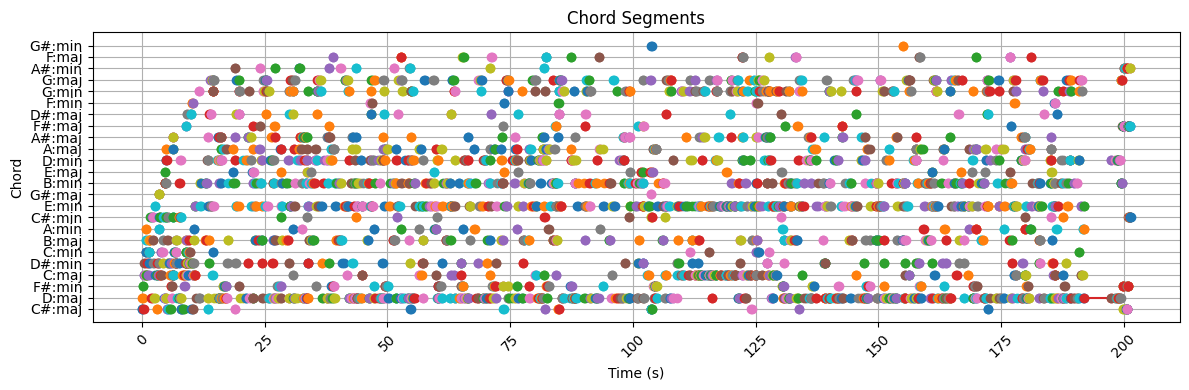

In [11]:
# Chord Identification with Tonnetz and Chroma

# ---- Compatibility shims for older librosa ↔ NumPy versions ----
import numpy as np
if not hasattr(np, "complex"):
    np.complex = complex  # noqa: NPY003 – compatibility shim
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int

# ---- Standard imports ----
import librosa
import pandas as pd
from pathlib import Path

# ------------------------
# 1. Load or synthesise audio
# ------------------------
# Set this to your own file, e.g. Path("my_song.wav")
audio_path = song_path

sr = 22_050  # target sample‑rate
if audio_path is None:
    # ---- Synthetic demo: C, G, Am, F (2 s each) ----
    dur = 2.0
    t = np.linspace(0, dur, int(sr * dur), endpoint=False)

    def sine(freq: float) -> np.ndarray:
        return np.sin(2 * np.pi * freq * t)

    def chord(midi: list[int]) -> np.ndarray:
        return sum(sine(440 * 2 ** ((m - 69) / 12)) for m in midi) / len(midi)

    progression = [[60, 64, 67], [67, 71, 74], [57, 60, 64], [65, 69, 72]]
    y = np.concatenate([chord(c) for c in progression])
else:
    y, sr = librosa.load(str(audio_path), sr=None)

# ------------------------
# 2. Feature extraction
# ------------------------
hop_length = 512
chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)
tonnetz = librosa.feature.tonnetz(chroma=chroma)

# ------------------------
# 3. Simple major/minor chord decoding via template matching
# ------------------------
major = np.zeros((12, 12))
minor = np.zeros((12, 12))
for root in range(12):
    major[root, [root, (root + 4) % 12, (root + 7) % 12]] = 1
    minor[root, [root, (root + 3) % 12, (root + 7) % 12]] = 1

templates = np.vstack([major, minor])
templates /= templates.sum(axis=1, keepdims=True)

scores = templates @ chroma
labels_idx = scores.argmax(axis=0)

note_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
chord_labels = [f"{note_names[i % 12]}:{'maj' if i < 12 else 'min'}" for i in range(24)]
labels = [chord_labels[i] for i in labels_idx]

# ------------------------
# 4. Merge contiguous frames into segments
# ------------------------
segments: list[tuple[str, int, int]] = []
cur = labels[0]
start = 0
for idx, lab in enumerate(labels):
    if lab != cur:
        segments.append((cur, start, idx - 1))
        cur, start = lab, idx
segments.append((cur, start, len(labels) - 1))

results = pd.DataFrame(
    [
        {
            "chord": lab,
            "start_time": round(s * hop_length / sr, 3),
            "end_time": round((e + 1) * hop_length / sr, 3),
        }
        for lab, s, e in segments
    ]
)


# Optionally save to CSV for DAW import
# results.to_csv("chords.csv", index=False)

print(results)

# plot a timeline with results

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
for _, row in results.iterrows():
    plt.plot([row['start_time'], row['end_time']], [row['chord'], row['chord']], marker='o')
plt.xlabel('Time (s)')
plt.ylabel('Chord')
plt.title('Chord Segments')
plt.xticks(rotation=45)     
plt.grid()
plt.tight_layout()
plt.show()
